# VDJBet YF Analysis (Rmd-aligned)

Python rewrite of `tmp/vdjbet_snippet.Rmd` with matching analysis outputs:

1. YF vs OLGA V-usage and V/J correction factors
2. LLW reference and adjusted mock generation
3. LLW Pgen histogram match against mock bins
4. LLW overlap per sample: matched clonotypes and duplicate_count
5. Cohen d, z-scores, empirical p-values, FDR
6. Red line (LLW) + mock boxplots and Cohen d heatmaps

In [ ]:
import math
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.basic.gene_usage import GeneUsage
from mir.basic.pgen import OlgaModel, PgenGeneUsageAdjustment
from mir.comparative.vdjbet import PgenBinPool, VDJBetOverlapAnalysis
from mir.common.parser import ClonotypeTableParser, load_vdjdb_latest
from mir.common.repertoire import LocusRepertoire, Repertoire
from mir.utils.notebook_assets import ensure_airr_yfv19, notebook_large_assets_root

SEED = 42
N_MOCKS = 200
POOL_SIZE = 200_000
OLGA_USAGE_N = 1_000_000
# count_rearrangement (default, unweighted) or count_duplicates (weighted by duplicate_count)
USAGE_COUNT_MODE = "count_rearrangement"
USAGE_PSEUDOCOUNT = 1.0
YFV_CACHE_DIRNAME = "pkl_trb_repertoires"

ASSET_ROOT = notebook_large_assets_root(repo_root)
YFV_DIR = ensure_airr_yfv19(repo_root)

print(f"YFV_DIR = {YFV_DIR}")
print(f"ASSET_ROOT = {ASSET_ROOT}")
print(f"Usage mode = {USAGE_COUNT_MODE}, pseudocount = {USAGE_PSEUDOCOUNT}")
print(f"OLGA usage cache size = {OLGA_USAGE_N:,}")

YFV_DIR = assets/large/yfv19
YFV_PRIMARY_DIR = notebooks/assets/large/yfv19
Usage mode = count_rearrangement, pseudocount = 1.0
OLGA usage cache size = 1,000,000


## 1. Load LLWNGPMAV TRB reference from VDJdb

In [2]:
vdjdb_rep = load_vdjdb_latest(
    epitope="LLWNGPMAV",
    locus="TRB",
    species="HomoSapiens",
    mhc_a_contains="A*02",
)
print(f"Reference clonotypes: {vdjdb_rep.clonotype_count}")
print(f"Example: {vdjdb_rep.clonotypes[0].junction_aa}  {vdjdb_rep.clonotypes[0].v_gene}  {vdjdb_rep.clonotypes[0].j_gene}")

Downloading: https://github.com/antigenomics/vdjdb-db/releases/download/2025-12-29/vdjdb-2025-12-29.zip
LLWNGPMAV: 409 unique TRB clonotypes
Reference clonotypes: 409
Example: CAIQDAGASYEQYF  TRBV6-2*01  TRBJ2-7*01


## 2. Load YF samples

In [3]:
# Load YF TRB repertoires and build per-sample records for VDJBet.
# Approx runtime: 15-60s on cached files, depending on parser/materialization.
from mir.common.filter import filter_functional
from mir.common.parser import ClonotypeTableParser
from mir.common.repertoire import LocusRepertoire, infer_locus

warnings.filterwarnings("ignore", category=FutureWarning)

def _parse_sample_filename(path: Path) -> tuple[str, int, str]:
    # Expected form: <donor>_<day>_<replica>.airr.tsv.gz  (e.g. S2_pre0_F1.airr.tsv.gz)
    stem = path.name
    if stem.endswith(".airr.tsv.gz"):
        stem = stem[:-len(".airr.tsv.gz")]
    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected sample filename format: {path.name}")
    donor = parts[0]
    day_token = parts[1].lower()
    replica = parts[2]

    if day_token.startswith("pre"):
        day = -1
    else:
        day = int(day_token)
    return donor, day, replica


parser = ClonotypeTableParser()
airr_files = sorted(YFV_DIR.glob("*.airr.tsv.gz"))
if not airr_files:
    raise FileNotFoundError(f"No AIRR files found in {YFV_DIR}")

samples = []
for fp in airr_files:
    donor, day, replica = _parse_sample_filename(fp)
    clonotypes = parser.parse(str(fp))
    for c in clonotypes:
        if not c.locus:
            c.locus = infer_locus(c.j_gene or c.v_gene or "")
    trb_clonotypes = [c for c in clonotypes if c.locus == "TRB"]
    trb_rep = LocusRepertoire(clonotypes=trb_clonotypes, locus="TRB", repertoire_id=fp.stem)
    trb_rep = filter_functional(trb_rep)
    if trb_rep.clonotype_count == 0:
        continue
    samples.append({
        "donor": donor,
        "day": day,
        "replica": replica,
        "sample_id": fp.stem,
        "repertoire": trb_rep,
    })

samples = sorted(samples, key=lambda x: (x["donor"], x["replica"], x["day"]))
yfv_gu = GeneUsage.from_list([s["repertoire"] for s in samples])

print(f"Loaded TRB samples: {len(samples)}")
print(f"Total TRB clonotypes: {sum(s['repertoire'].clonotype_count for s in samples):,}")
print(f"Total TRB duplicates: {sum(s['repertoire'].duplicate_count for s in samples):,}")

Loaded TRB samples: 42
Total TRB clonotypes: 29,939,151
Total TRB duplicates: 56,732,204


## 3. OLGA usage and correction factors

Compute OLGA and YF usage frequencies, then derive correction factors.

Frequencies are computed in GeneUsage with configurable count mode and Laplace smoothing:

- mode count_rearrangement: count of unique clonotypes per key / total clonotypes
- mode count_duplicates: sum duplicate_count per key / total duplicate_count
- pseudocount 1 is added for both YF and OLGA sides

Formulas:

- factor_v = P_YF(V) / P_OLGA(V)
- factor_vj = P_YF(V,J) / P_OLGA(V,J)

These factors are used by PgenGeneUsageAdjustment.

Top V genes by |log2 factor|:


,v_gene,p_yf,p_olga,factor_v,log2_factor_v,abs_log2
42,TRBV7-4,0.000514,0.012749,0.040343,-4.631555,4.631555
34,TRBV6-3,0.000602,0.011138,0.054040,-4.209835,4.209835
38,TRBV6-8,0.000327,0.002933,0.111426,-3.165847,3.165847
39,TRBV6-9,0.000210,0.001870,0.112086,-3.157317,3.157317
0,TRBV10-1,0.003474,0.027080,0.128293,-2.962484,2.962484
9,TRBV13,0.004602,0.033846,0.135971,-2.878629,2.878629
35,TRBV6-4,0.004885,0.035437,0.137852,-2.858808,2.858808
5,TRBV11-3,0.004155,0.020397,0.203725,-2.295303,2.295303
6,TRBV12-3,0.071966,0.016561,4.345486,2.119518,2.119518
8,TRBV12-5,0.003422,0.012899,0.265258,-1.914530,1.914530


Top VJ pairs by |log2 factor|:


,v_gene,j_gene,p_yf,p_olga,factor_vj,log2_factor_vj,abs_log2
565,TRBV7-4,TRBJ1-2,0.000024,0.001308,0.018358,-5.767464,5.767464
71,TRBV11-3,TRBJ1-5,0.000054,0.002188,0.024551,-5.348067,5.348067
575,TRBV7-4,TRBJ2-6,0.000006,0.000215,0.025805,-5.276216,5.276216
473,TRBV6-4,TRBJ1-3,0.000030,0.001116,0.026720,-5.225959,5.225959
564,TRBV7-4,TRBJ1-1,0.000040,0.001486,0.027241,-5.198077,5.198077
474,TRBV6-4,TRBJ1-4,0.000049,0.001680,0.028948,-5.110372,5.110372
569,TRBV7-4,TRBJ1-6,0.000015,0.000464,0.031765,-4.976408,4.976408
567,TRBV7-4,TRBJ1-4,0.000019,0.000586,0.032053,-4.963393,4.963393
462,TRBV6-3,TRBJ1-5,0.000039,0.001177,0.033308,-4.907969,4.907969
124,TRBV13,TRBJ1-5,0.000127,0.003594,0.035262,-4.825736,4.825736


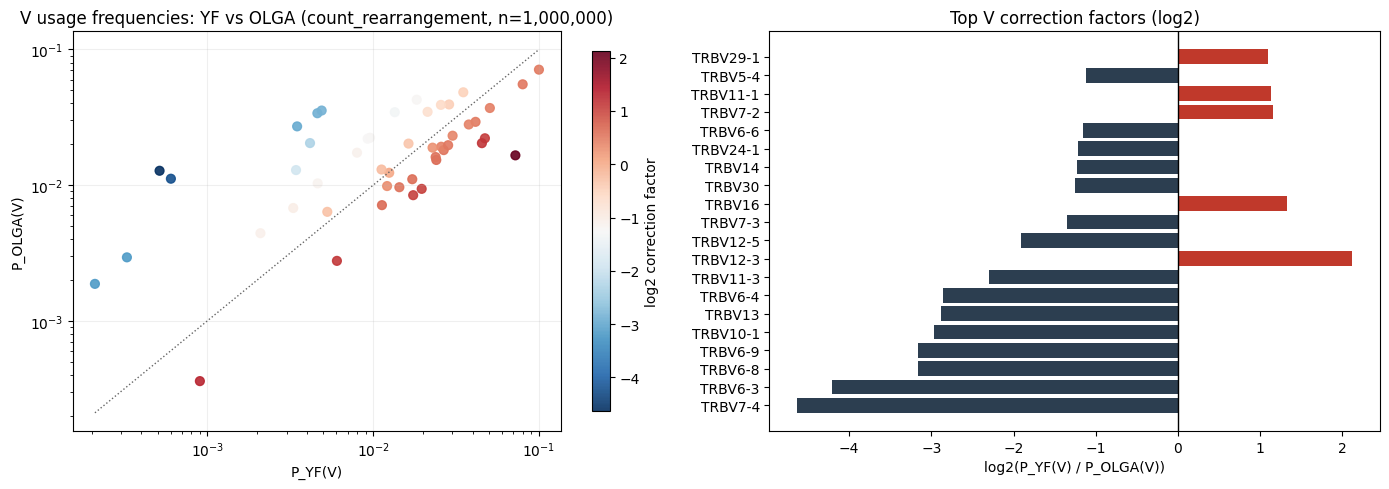

Zero-frequency OLGA V genes in comparison table: 0


In [4]:
olga_model = OlgaModel(locus="TRB", seed=SEED)
olga_gu = olga_model.compute_usage_cache(n=OLGA_USAGE_N, seed=SEED)

# Centralized frequency + factor computation from GeneUsage module
v_cmp = yfv_gu.usage_comparison(
    olga_gu,
    "TRB",
    scope="v",
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)
vj_cmp = yfv_gu.usage_comparison(
    olga_gu,
    "TRB",
    scope="vj",
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)

v_df = pd.DataFrame(
    [
        {
            "v_gene": k,
            "p_yf": vals["p_self"],
            "p_olga": vals["p_reference"],
            "factor_v": vals["factor"],
        }
        for k, vals in v_cmp.items()
    ]
)
v_df["log2_factor_v"] = np.log2(np.clip(v_df["factor_v"].values, 1e-300, None))

vj_df = pd.DataFrame(
    [
        {
            "v_gene": k[0],
            "j_gene": k[1],
            "p_yf": vals["p_self"],
            "p_olga": vals["p_reference"],
            "factor_vj": vals["factor"],
        }
        for k, vals in vj_cmp.items()
    ]
)
vj_df["log2_factor_vj"] = np.log2(np.clip(vj_df["factor_vj"].values, 1e-300, None))

pgen_adj = PgenGeneUsageAdjustment(
    yfv_gu,
    cache_size=OLGA_USAGE_N,
    seed=SEED,
    count=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
    reference=olga_gu,
)

print("Top V genes by |log2 factor|:")
display(v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(15))
print("Top VJ pairs by |log2 factor|:")
display(vj_df.assign(abs_log2=lambda d: d["log2_factor_vj"].abs()).sort_values("abs_log2", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.clip(v_df["p_yf"].values, 1e-12, None)
y = np.clip(v_df["p_olga"].values, 1e-12, None)
sc = axes[0].scatter(x, y, c=v_df["log2_factor_v"].values, cmap="RdBu_r", s=40, alpha=0.9)
axes[0].plot([x.min(), x.max()], [x.min(), x.max()], color="#666666", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("P_YF(V)")
axes[0].set_ylabel("P_OLGA(V)")
axes[0].set_title(f"V usage frequencies: YF vs OLGA ({USAGE_COUNT_MODE}, n={OLGA_USAGE_N:,})")
axes[0].grid(alpha=0.2)
cb = plt.colorbar(sc, ax=axes[0], shrink=0.9)
cb.set_label("log2 correction factor")

top = v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(20)
axes[1].barh(top["v_gene"], top["log2_factor_v"], color=["#c0392b" if z > 0 else "#2c3e50" for z in top["log2_factor_v"]])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Top V correction factors (log2)")
axes[1].set_xlabel("log2(P_YF(V) / P_OLGA(V))")

plt.tight_layout()
plt.show()

print(f"Zero-frequency OLGA V genes in comparison table: {(v_df['p_olga'] == 0).sum()}")

### Runtime note

Approx runtime for the next cell (mock pool generation + LLW diagnostics): **4-8 minutes** on a laptop CPU.

Main driver is `POOL_SIZE` and OLGA calls; reduce `POOL_SIZE` for quicker exploratory runs.

Pool built: n_generated=200,000, bins=62, floor=-79, ceil=-18, elapsed=0.5s


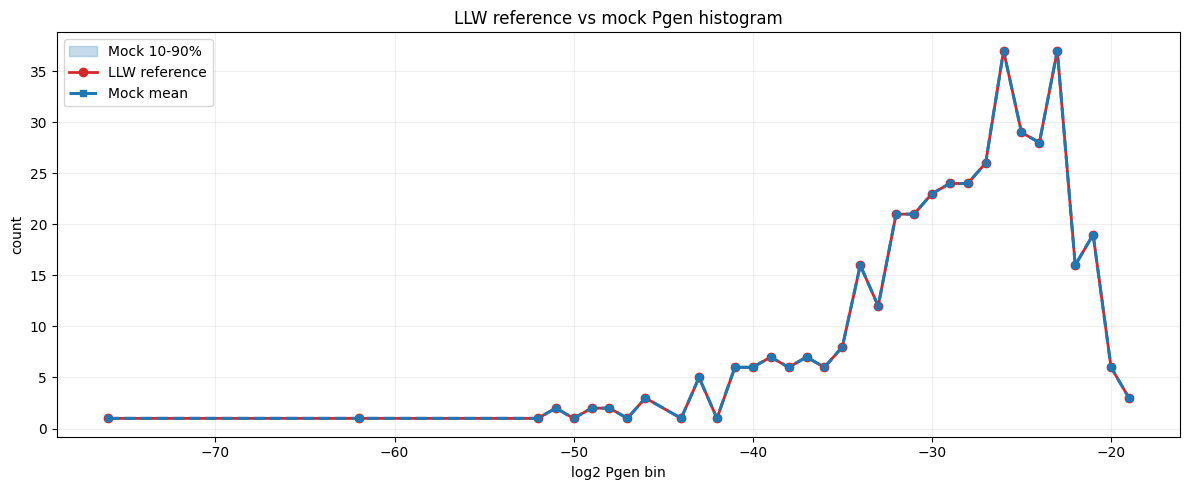

Mock vs LLW: median max|Delta p(bin)|=0.0000, p95=0.0000
Mock vs LLW: median RMSD=0.0000, p95=0.0000


In [5]:
t0 = pd.Timestamp.now()
pool = PgenBinPool(
    "TRB",
    n=POOL_SIZE,
    n_jobs=4,
    seed=SEED,
    pgen_adjustment=pgen_adj,
)
analysis = VDJBetOverlapAnalysis(
    vdjdb_rep,
    pool=pool,
    n_mocks=N_MOCKS,
    seed=SEED,
)
dt = (pd.Timestamp.now() - t0).total_seconds()
print(f"Pool built: n_generated={pool.n_generated:,}, bins={len(pool.bins)}, floor={pool.floor_bin}, ceil={pool.ceil_bin}, elapsed={dt:.1f}s")

ref_bins = analysis.get_reference_bin_sample()
mock_bins = analysis.get_mock_bin_samples()

ref_counts = Counter(ref_bins)
all_bins = sorted(ref_counts.keys())
if not all_bins:
    raise RuntimeError("No LLW reference bins available for diagnostics.")

mock_mat = []
for mb in mock_bins:
    mc = Counter(mb)
    mock_mat.append([mc.get(b, 0) for b in all_bins])
mock_mat = np.asarray(mock_mat, dtype=float)

ref_vec = np.array([ref_counts.get(b, 0) for b in all_bins], dtype=float)
mock_mean = mock_mat.mean(axis=0)
mock_q10 = np.quantile(mock_mat, 0.10, axis=0)
mock_q90 = np.quantile(mock_mat, 0.90, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(all_bins, mock_q10, mock_q90, alpha=0.25, color="#1f77b4", label="Mock 10-90%", zorder=1)
ax.plot(all_bins, ref_vec, color="#d62728", marker="o", linewidth=2, label="LLW reference", zorder=2)
# Draw mock mean last so it remains visible even when overlapping the reference line.
ax.plot(all_bins, mock_mean, color="#1f77b4", linestyle="--", marker="s", markersize=4, linewidth=2.2, label="Mock mean", zorder=3)
ax.set_xlabel("log2 Pgen bin")
ax.set_ylabel("count")
ax.set_title("LLW reference vs mock Pgen histogram")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

ref_prob = ref_vec / max(ref_vec.sum(), 1.0)
mock_probs = mock_mat / np.clip(mock_mat.sum(axis=1, keepdims=True), 1.0, None)
max_abs_diff = np.max(np.abs(mock_probs - ref_prob[None, :]), axis=1)
rmsd = np.sqrt(np.mean((mock_probs - ref_prob[None, :]) ** 2, axis=1))
print(f"Mock vs LLW: median max|Delta p(bin)|={np.median(max_abs_diff):.4f}, p95={np.percentile(max_abs_diff,95):.4f}")
print(f"Mock vs LLW: median RMSD={np.median(rmsd):.4f}, p95={np.percentile(rmsd,95):.4f}")

## 5. LLW overlap per sample: matched clonotypes and duplicate_count

Compute for each donor/day/replica:
- real LLW overlap
- mock distribution summary
- z-score and empirical p-value
- Cohen d
- FDR-adjusted p-values

In [6]:
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out

rows = []
for i, s in enumerate(samples, start=1):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        r = analysis.score(s["repertoire"], allow_1mm=False, match_v=True, match_j=True)

    mn = np.array(r.mock_n, dtype=float)
    mdc = np.array(r.mock_dc, dtype=float)
    mdc_log2 = np.log2(mdc + 1.0)
    real_dc_log2 = math.log2(r.dc + 1.0)

    mn_mean = float(np.mean(mn))
    mn_sd = float(np.std(mn, ddof=1)) if len(mn) > 1 else 0.0
    mdc_mean = float(np.mean(mdc_log2))
    mdc_sd = float(np.std(mdc_log2, ddof=1)) if len(mdc_log2) > 1 else 0.0

    z_n = (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0
    z_dc = (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0

    p_n_emp = (np.sum(mn >= r.n) + 1.0) / (len(mn) + 1.0)
    p_dc_emp = (np.sum(mdc_log2 >= real_dc_log2) + 1.0) / (len(mdc_log2) + 1.0)

    rows.append({
        "donor": s["donor"],
        "day": s["day"],
        "replica": s["replica"],
        "sample_label": f"{s['donor']} {s['replica']}",
        "n_total": r.n_total,
        "dc_total": r.dc_total,
        "matched_n_real": float(r.n),
        "matched_n_mock_mean": mn_mean,
        "matched_n_mock_sd": mn_sd,
        "matched_n_z": z_n,
        "matched_n_p_emp": p_n_emp,
        "matched_n_cohen_d": (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0,
        "matched_dc_real": float(r.dc),
        "matched_dc_log2_real": real_dc_log2,
        "matched_dc_log2_mock_mean": mdc_mean,
        "matched_dc_log2_mock_sd": mdc_sd,
        "matched_dc_log2_z": z_dc,
        "matched_dc_log2_p_emp": p_dc_emp,
        "matched_dc_log2_cohen_d": (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0,
        "mock_n": list(mn),
        "mock_dc_log2": list(mdc_log2),
    })

    if i % 10 == 0:
        print(f"Processed {i}/{len(samples)} samples")

df_res = pd.DataFrame(rows).sort_values(["donor", "replica", "day"]).reset_index(drop=True)
df_res["matched_n_p_adj"] = bh_fdr(df_res["matched_n_p_emp"].values)
df_res["matched_dc_log2_p_adj"] = bh_fdr(df_res["matched_dc_log2_p_emp"].values)

display(df_res[[
    "donor", "replica", "day",
    "matched_n_real", "matched_n_mock_mean", "matched_n_z", "matched_n_p_emp", "matched_n_cohen_d",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_cohen_d",
]])

Processed 10/42 samples
Processed 20/42 samples
Processed 30/42 samples
Processed 40/42 samples


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_z,matched_n_p_emp,matched_n_cohen_d,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_cohen_d
0,P1,F1,-1,11.0,7.630,1.208047,0.159204,1.208047,55.0,5.807355,3.919786,2.220697,0.019900,2.220697
1,P1,F1,0,13.0,6.790,2.353775,0.019900,2.353775,48.0,5.614710,3.551832,2.692525,0.009950,2.692525
2,P1,F1,7,21.0,9.440,4.362572,0.004975,4.362572,100.0,6.658211,4.384744,3.139526,0.004975,3.139526
3,P1,F1,15,28.0,9.640,5.817530,0.004975,5.817530,364.0,8.511753,4.416095,5.539278,0.004975,5.539278
4,P1,F1,45,18.0,7.110,4.012820,0.004975,4.012820,432.0,8.758223,3.684443,6.750670,0.004975,6.750670
5,P1,F2,0,11.0,6.435,1.933620,0.044776,1.933620,45.0,5.523562,3.494338,2.792180,0.004975,2.792180
6,P2,F1,-1,20.0,11.880,2.252031,0.019900,2.252031,61.0,5.954196,4.804687,1.599210,0.054726,1.599210
7,P2,F1,0,16.0,7.300,3.205375,0.009950,3.205375,41.0,5.392317,3.746208,2.340685,0.009950,2.340685
8,P2,F1,7,29.0,11.600,4.918992,0.004975,4.918992,88.0,6.475733,4.783144,2.229868,0.009950,2.229868
9,P2,F1,15,34.0,11.775,7.584259,0.004975,7.584259,278.0,8.124121,4.729488,5.380098,0.004975,5.380098


### Runtime note

Approx runtime for plotting and effect-size summary cells below: **under 1 minute** total after scoring is complete.

Most time is spent in figure rendering, not in overlap recomputation.

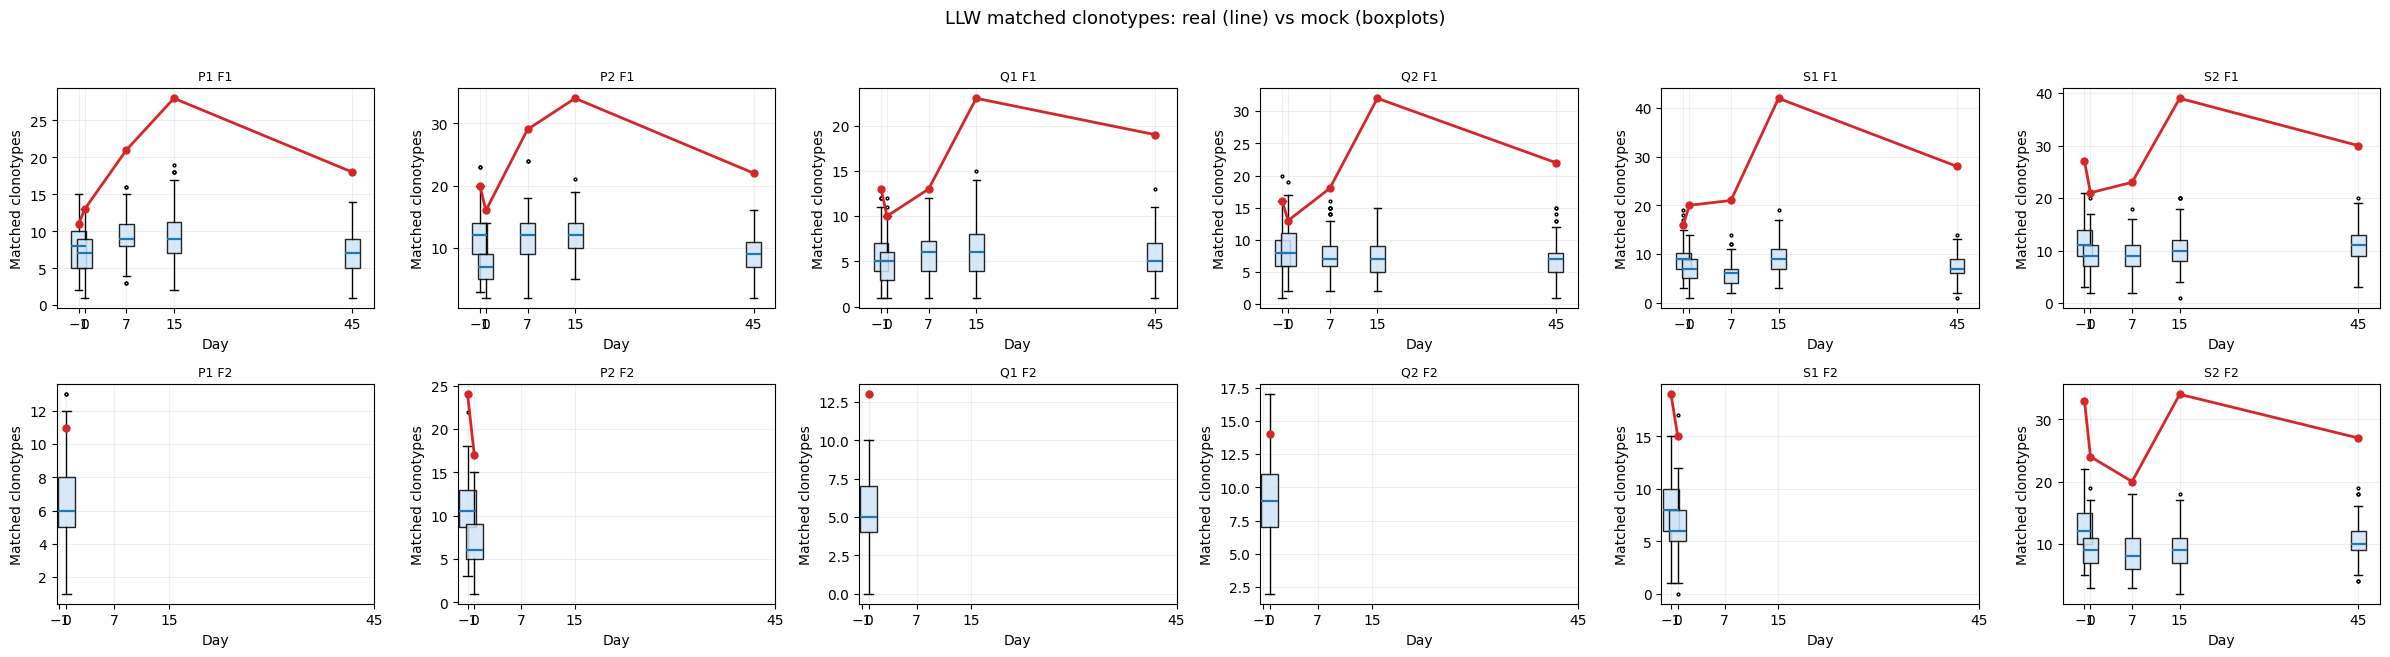

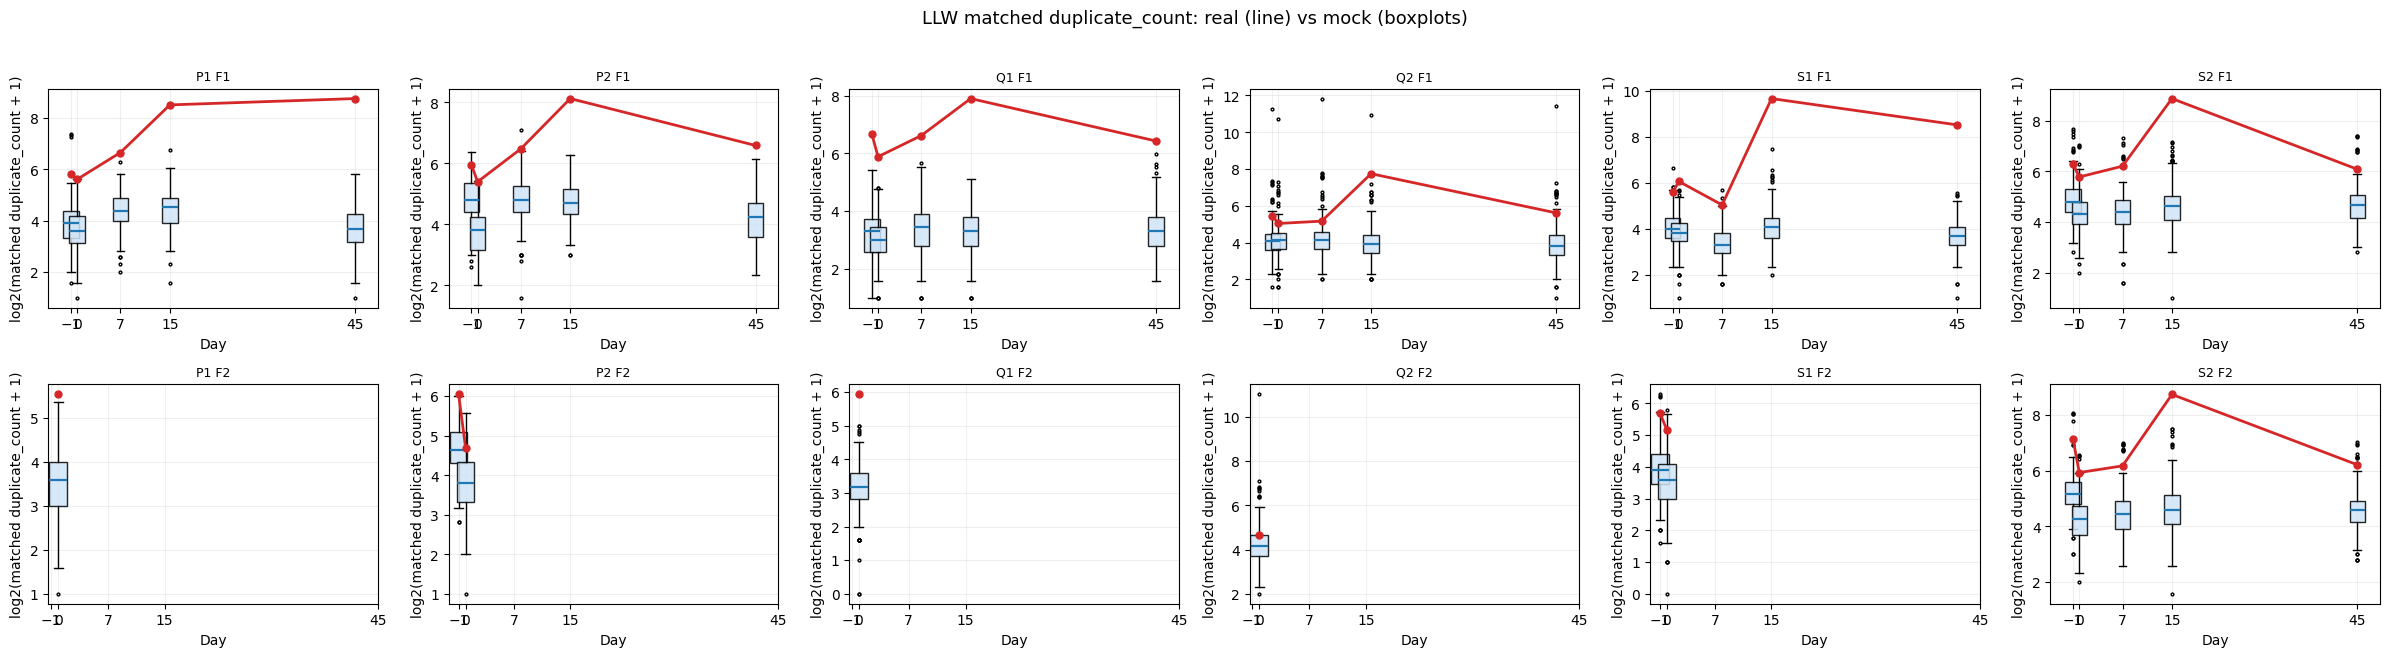

In [7]:
plot_rows = []
for _, r in df_res.iterrows():
    for x in r["mock_n"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_n", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_n", "kind": "real", "value": float(r["matched_n_real"]),
    })

    for x in r["mock_dc_log2"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_dc_log2", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_dc_log2", "kind": "real", "value": float(r["matched_dc_log2_real"]),
    })

plot_df = pd.DataFrame(plot_rows)
days_all = sorted(df_res["day"].unique().tolist())
donors = sorted(df_res["donor"].unique().tolist())
replicas = sorted(df_res["replica"].unique().tolist())

def draw_panel(metric, ylabel, title):
    fig, axes = plt.subplots(len(replicas), len(donors), figsize=(4.0 * len(donors), 3.2 * len(replicas)), squeeze=False)
    fig.suptitle(title, fontsize=13, y=1.02)
    for ri, rep in enumerate(replicas):
        for di, donor in enumerate(donors):
            ax = axes[ri, di]
            sub = plot_df[(plot_df["metric"] == metric) & (plot_df["donor"] == donor) & (plot_df["replica"] == rep)]
            if sub.empty:
                ax.set_visible(False)
                continue

            real = sub[sub["kind"] == "real"].sort_values("day")
            mock = sub[sub["kind"] == "mock"]
            box_data = [mock[mock["day"] == d]["value"].values for d in days_all]
            width = 2.5
            ax.boxplot(
                box_data,
                positions=days_all,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="#d0e4f7", alpha=0.85),
                medianprops=dict(color="#1f77b4", linewidth=1.6),
                flierprops=dict(markersize=2),
                manage_ticks=False,
            )
            ax.plot(real["day"], real["value"], "-o", color="#d62728", linewidth=2, markersize=5, zorder=5)
            ax.set_xticks(days_all)
            ax.set_xlabel("Day")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{donor} {rep}", fontsize=9)
            ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

draw_panel("matched_n", "Matched clonotypes", "LLW matched clonotypes: real (line) vs mock (boxplots)")
draw_panel("matched_dc_log2", "log2(matched duplicate_count + 1)", "LLW matched duplicate_count: real (line) vs mock (boxplots)")

## 7. Cohen d heatmaps

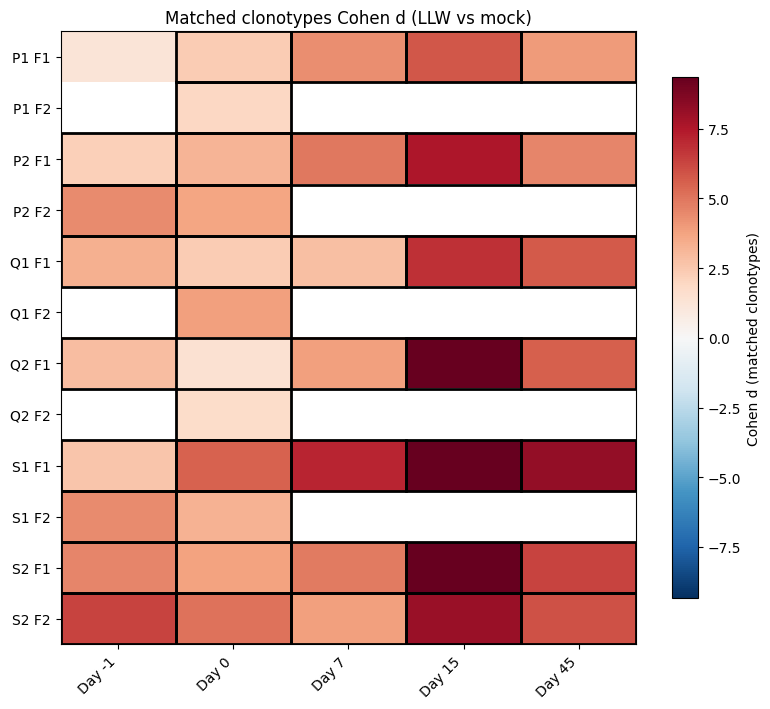

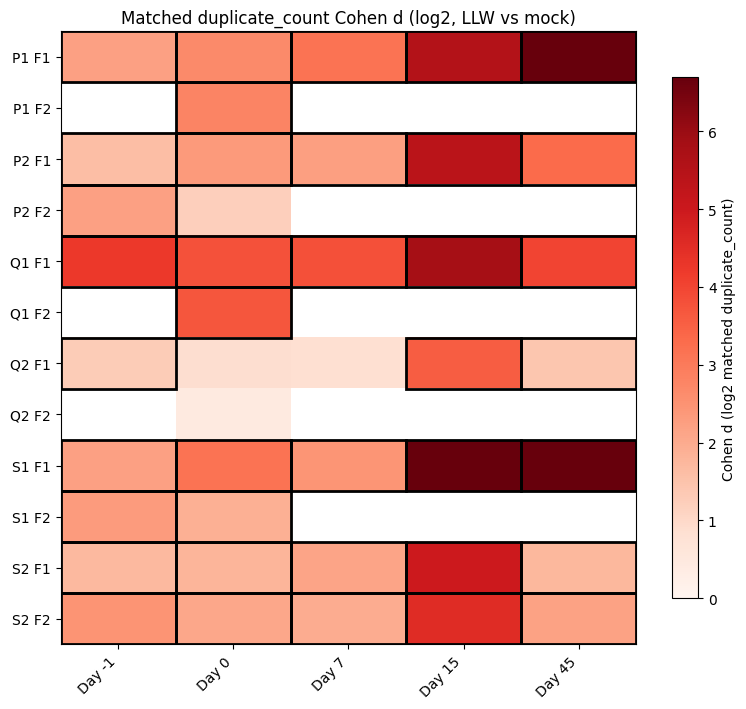

In [8]:
def heatmap_cohen(value_col, p_adj_col, title, cbar_label, cmap="RdBu_r", vlim=None):
    work = df_res.copy()
    work["sample"] = work["donor"] + " " + work["replica"]
    pv = work.pivot_table(index="sample", columns="day", values=value_col, aggfunc="first")
    pp = work.pivot_table(index="sample", columns="day", values=p_adj_col, aggfunc="first")

    mat = pv.values.astype(float)
    if vlim is None:
        vmax = max(1.0, np.nanpercentile(np.abs(mat), 95))
        vmin = -vmax
    else:
        vmin, vmax = vlim

    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.6 * pv.shape[0])))
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax, interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(cbar_label)

    for r in range(pv.shape[0]):
        for c in range(pv.shape[1]):
            p = pp.values[r, c]
            d = pv.values[r, c]
            if pd.notna(p) and pd.notna(d) and (float(p) < 0.10) and (float(d) > 0):
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([f"Day {d}" for d in pv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

heatmap_cohen(
    value_col="matched_n_cohen_d",
    p_adj_col="matched_n_p_adj",
    title="Matched clonotypes Cohen d (LLW vs mock)",
    cbar_label="Cohen d (matched clonotypes)",
    cmap="RdBu_r",
)

heatmap_cohen(
    value_col="matched_dc_log2_cohen_d",
    p_adj_col="matched_dc_log2_p_adj",
    title="Matched duplicate_count Cohen d (log2, LLW vs mock)",
    cbar_label="Cohen d (log2 matched duplicate_count)",
    cmap="Reds",
    vlim=(0, max(1.0, np.nanpercentile(df_res["matched_dc_log2_cohen_d"].values, 95))),
)

## 8. Final summary tables

In [9]:
summary_cols = [
    "donor", "replica", "day",
    "matched_n_real", "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z", "matched_n_p_emp", "matched_n_p_adj",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj",
]
summary = df_res[summary_cols].copy()
for col in [
    "matched_n_real", "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z",
    "matched_dc_real", "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z",
]:
    summary[col] = summary[col].astype(float).round(3)
for col in ["matched_n_p_emp", "matched_n_p_adj", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

display(summary.sort_values(["donor", "replica", "day"]).reset_index(drop=True))

print("Top positive matched clonotype effects by Cohen d:")
display(summary.sort_values("matched_n_cohen_d", ascending=False).head(12))

print("Top positive matched duplicate_count effects by Cohen d:")
display(summary.sort_values("matched_dc_log2_cohen_d", ascending=False).head(12))

,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
0,P1,F1,-1,11.0,7.630,2.790,1.208,1.208,0.1592,0.1592,55.0,5.807,3.920,0.850,2.221,2.221,0.0199,0.0334
1,P1,F1,0,13.0,6.790,2.638,2.354,2.354,0.0199,0.0232,48.0,5.615,3.552,0.766,2.693,2.693,0.0100,0.0190
2,P1,F1,7,21.0,9.440,2.650,4.363,4.363,0.0050,0.0070,100.0,6.658,4.385,0.724,3.140,3.140,0.0050,0.0116
3,P1,F1,15,28.0,9.640,3.156,5.818,5.818,0.0050,0.0070,364.0,8.512,4.416,0.739,5.539,5.539,0.0050,0.0116
4,P1,F1,45,18.0,7.110,2.714,4.013,4.013,0.0050,0.0070,432.0,8.758,3.684,0.752,6.751,6.751,0.0050,0.0116
5,P1,F2,0,11.0,6.435,2.361,1.934,1.934,0.0448,0.0482,45.0,5.524,3.494,0.727,2.792,2.792,0.0050,0.0116
6,P2,F1,-1,20.0,11.880,3.606,2.252,2.252,0.0199,0.0232,61.0,5.954,4.805,0.719,1.599,1.599,0.0547,0.0638
7,P2,F1,0,16.0,7.300,2.714,3.205,3.205,0.0100,0.0131,41.0,5.392,3.746,0.703,2.341,2.341,0.0100,0.0190
8,P2,F1,7,29.0,11.600,3.537,4.919,4.919,0.0050,0.0070,88.0,6.476,4.783,0.759,2.230,2.230,0.0100,0.0190
9,P2,F1,15,34.0,11.775,2.930,7.584,7.584,0.0050,0.0070,278.0,8.124,4.729,0.631,5.380,5.380,0.0050,0.0116


Top positive matched clonotype effects by Cohen d:


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,42.0,8.895,2.754,12.023,12.023,0.0050,0.0070,814.0,9.671,4.097,0.763,7.304,7.304,0.0050,0.0116
35,S2,F1,15,39.0,10.160,3.025,9.534,9.534,0.0050,0.0070,471.0,8.883,4.670,0.848,4.969,4.969,0.0050,0.0116
22,Q2,F1,15,32.0,7.300,2.628,9.400,9.400,0.0050,0.0070,214.0,7.748,4.025,1.041,3.576,3.576,0.0100,0.0190
29,S1,F1,45,28.0,7.305,2.515,8.230,8.230,0.0050,0.0070,368.0,8.527,3.701,0.716,6.740,6.740,0.0050,0.0116
40,S2,F2,15,34.0,9.470,3.031,8.094,8.094,0.0050,0.0070,424.0,8.731,4.604,0.908,4.546,4.546,0.0050,0.0116
9,P2,F1,15,34.0,11.775,2.930,7.584,7.584,0.0050,0.0070,278.0,8.124,4.729,0.631,5.380,5.380,0.0050,0.0116
27,S1,F1,7,21.0,5.875,2.122,7.129,7.129,0.0050,0.0070,32.0,5.044,3.350,0.696,2.436,2.436,0.0149,0.0273
16,Q1,F1,15,23.0,6.125,2.482,6.799,6.799,0.0050,0.0070,237.0,7.895,3.318,0.787,5.819,5.819,0.0050,0.0116
37,S2,F2,-1,33.0,12.480,3.255,6.305,6.305,0.0050,0.0070,138.0,7.119,5.205,0.774,2.473,2.473,0.0249,0.0360
36,S2,F1,45,30.0,10.940,3.029,6.293,6.293,0.0050,0.0070,67.0,6.087,4.684,0.807,1.740,1.740,0.0448,0.0570


Top positive matched duplicate_count effects by Cohen d:


,donor,replica,day,matched_n_real,matched_n_mock_mean,matched_n_mock_sd,matched_n_cohen_d,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_real,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,42.0,8.895,2.754,12.023,12.023,0.0050,0.0070,814.0,9.671,4.097,0.763,7.304,7.304,0.0050,0.0116
4,P1,F1,45,18.0,7.110,2.714,4.013,4.013,0.0050,0.0070,432.0,8.758,3.684,0.752,6.751,6.751,0.0050,0.0116
29,S1,F1,45,28.0,7.305,2.515,8.230,8.230,0.0050,0.0070,368.0,8.527,3.701,0.716,6.740,6.740,0.0050,0.0116
16,Q1,F1,15,23.0,6.125,2.482,6.799,6.799,0.0050,0.0070,237.0,7.895,3.318,0.787,5.819,5.819,0.0050,0.0116
3,P1,F1,15,28.0,9.640,3.156,5.818,5.818,0.0050,0.0070,364.0,8.512,4.416,0.739,5.539,5.539,0.0050,0.0116
9,P2,F1,15,34.0,11.775,2.930,7.584,7.584,0.0050,0.0070,278.0,8.124,4.729,0.631,5.380,5.380,0.0050,0.0116
35,S2,F1,15,39.0,10.160,3.025,9.534,9.534,0.0050,0.0070,471.0,8.883,4.670,0.848,4.969,4.969,0.0050,0.0116
40,S2,F2,15,34.0,9.470,3.031,8.094,8.094,0.0050,0.0070,424.0,8.731,4.604,0.908,4.546,4.546,0.0050,0.0116
13,Q1,F1,-1,13.0,5.365,2.280,3.349,3.349,0.0050,0.0070,101.0,6.672,3.213,0.814,4.252,4.252,0.0050,0.0116
17,Q1,F1,45,19.0,5.635,2.334,5.725,5.725,0.0050,0.0070,85.0,6.426,3.344,0.767,4.020,4.020,0.0050,0.0116


Notebook output coverage checklist:

- V usage YF vs OLGA and correction factors
- LLW reference vs mock Pgen histogram alignment
- Matched clonotypes and duplicate_count per sample
- Cohen d, z-scores, empirical p-values, FDR
- Line + boxplot dynamics and Cohen d heatmaps

In [10]:
print("Done: notebook rewritten to Rmd-aligned workflow.")
print(f"Samples: {len(samples)}, mocks: {N_MOCKS}, pool size: {POOL_SIZE:,}")
print("Use the summary table above for export/reporting.")

Done: notebook rewritten to Rmd-aligned workflow.
Samples: 42, mocks: 200, pool size: 200,000
Use the summary table above for export/reporting.


## 9. Mock real control and side-by-side comparison

This section duplicates the overlap analysis with a mock pool sampled from real control data (human TRB), then compares:

- mock synthetic
- mock real
- mock synthetic scaled by factor $X$

where $X$ is chosen so that the mean mock overlap for synthetic matches the mean mock overlap for real.

In [11]:
import importlib
import mir.common.control as _ctrl_mod
import mir.comparative.vdjbet as _vdjbet_mod
importlib.reload(_ctrl_mod)
importlib.reload(_vdjbet_mod)
from mir.comparative.vdjbet import PgenBinPool, VDJBetOverlapAnalysis
print('Reloaded mir.common.control and mir.comparative.vdjbet from source')

Reloaded mir.common.control and mir.comparative.vdjbet from source


In [12]:
from mir.comparative.vdjbet import PgenBinPool





def _score_with_existing_metrics(analysis_obj, samples_list):

    rows_local = []

    for i, s in enumerate(samples_list, start=1):

        with warnings.catch_warnings():

            warnings.simplefilter("ignore", UserWarning)

            r = analysis_obj.score(s["repertoire"], allow_1mm=False, match_v=True, match_j=True)



        mn = np.array(r.mock_n, dtype=float)

        mdc = np.array(r.mock_dc, dtype=float)

        mdc_log2 = np.log2(mdc + 1.0)

        real_dc_log2 = math.log2(r.dc + 1.0)



        mn_mean = float(np.mean(mn))

        mn_sd = float(np.std(mn, ddof=1)) if len(mn) > 1 else 0.0

        mdc_mean = float(np.mean(mdc_log2))

        mdc_sd = float(np.std(mdc_log2, ddof=1)) if len(mdc_log2) > 1 else 0.0



        z_n = (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0

        z_dc = (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0



        p_n_emp = (np.sum(mn >= r.n) + 1.0) / (len(mn) + 1.0)

        p_dc_emp = (np.sum(mdc_log2 >= real_dc_log2) + 1.0) / (len(mdc_log2) + 1.0)



        rows_local.append(

            {

                "donor": s["donor"],

                "day": s["day"],

                "replica": s["replica"],

                "sample_label": f"{s['donor']} {s['replica']}",

                "matched_n_real": float(r.n),

                "matched_n_mock_mean": mn_mean,

                "matched_n_mock_sd": mn_sd,

                "matched_n_z": z_n,

                "matched_n_p_emp": p_n_emp,

                "matched_n_cohen_d": (r.n - mn_mean) / mn_sd if mn_sd > 0 else 0.0,

                "matched_dc_real": float(r.dc),

                "matched_dc_log2_real": real_dc_log2,

                "matched_dc_log2_mock_mean": mdc_mean,

                "matched_dc_log2_mock_sd": mdc_sd,

                "matched_dc_log2_z": z_dc,

                "matched_dc_log2_p_emp": p_dc_emp,

                "matched_dc_log2_cohen_d": (real_dc_log2 - mdc_mean) / mdc_sd if mdc_sd > 0 else 0.0,

                "mock_n": list(mn),

                "mock_dc_log2": list(mdc_log2),

            }

        )



        if i % 10 == 0:

            print(f"Scored {i}/{len(samples_list)} for current analysis")



    out = pd.DataFrame(rows_local).sort_values(["donor", "replica", "day"]).reset_index(drop=True)

    out["matched_n_p_adj"] = bh_fdr(out["matched_n_p_emp"].values)

    out["matched_dc_log2_p_adj"] = bh_fdr(out["matched_dc_log2_p_emp"].values)

    return out





pool_real = PgenBinPool.from_control(

    locus="TRB",

    control_type="real",

    species="human",

    n=POOL_SIZE,

    n_jobs=4,

    seed=SEED,

)

analysis_real = VDJBetOverlapAnalysis(vdjdb_rep, pool=pool_real, n_mocks=N_MOCKS, seed=SEED)



df_res_synth = df_res.copy()

df_res_real = _score_with_existing_metrics(analysis_real, samples)



X_scale = float(df_res_real["matched_n_mock_mean"].mean() / max(df_res_synth["matched_n_mock_mean"].mean(), 1e-12))

df_res_synth_scaled = df_res_synth.copy()

df_res_synth_scaled["matched_n_mock_mean"] = df_res_synth_scaled["matched_n_mock_mean"] * X_scale

df_res_synth_scaled["matched_n_mock_sd"] = df_res_synth_scaled["matched_n_mock_sd"] * X_scale

df_res_synth_scaled["mock_n"] = df_res_synth_scaled["mock_n"].apply(lambda xs: [float(x) * X_scale for x in xs])



print(f"Real-control pool records used: {pool_real.n_generated:,}")

print(f"Synthetic mock mean overlap: {df_res_synth['matched_n_mock_mean'].mean():.4f}")

print(f"Real-data mock mean overlap: {df_res_real['matched_n_mock_mean'].mean():.4f}")

print(f"Scale factor X (real/synthetic): {X_scale:.4f}")


Scored 10/42 for current analysis
Scored 20/42 for current analysis
Scored 30/42 for current analysis
Scored 40/42 for current analysis
Real-control pool records used: 199,971
Synthetic mock mean overlap: 8.3183
Real-data mock mean overlap: 23.1237
Scale factor X (real/synthetic): 2.7798


In [13]:
sig_n_real = df_res_real[(df_res_real["matched_n_p_adj"] < 0.10) & (df_res_real["matched_n_cohen_d"] > 0)]
sig_dc_real = df_res_real[(df_res_real["matched_dc_log2_p_adj"] < 0.10) & (df_res_real["matched_dc_log2_cohen_d"] > 0)]

def _as_triplet_set(df):
    return {(r.donor, r.replica, int(r.day)) for r in df[["donor", "replica", "day"]].itertuples(index=False)}

def _as_label_list(df):
    return [f"{r.donor} {r.replica} day {int(r.day)}" for r in df[["donor", "replica", "day"]].itertuples(index=False)]

expected_sig_n = {
    ("S2", "F1", 15),
    ("S1", "F1", 15),
    ("Q2", "F1", 15),
    ("Q1", "F1", 15),
}
expected_sig_dc = {
    ("S2", "F1", 15),
    ("S2", "F2", 15),
    ("S1", "F1", 15),
    ("S1", "F1", 45),
    ("Q1", "F1", 15),
    ("P2", "F1", 15),
    ("P1", "F1", 15),
    ("P1", "F1", 45),
}

set_sig_n = _as_triplet_set(sig_n_real)
set_sig_dc = _as_triplet_set(sig_dc_real)

print("Observed significant matched clonotypes (FDR<0.10, d>0):")
print(_as_label_list(sig_n_real))
print("Observed significant matched duplicate_count log2 (FDR<0.10, d>0):")
print(_as_label_list(sig_dc_real))

print("\nExpectation check: matched clonotypes")
print("match:", set_sig_n == expected_sig_n)
print("missing:", sorted(expected_sig_n - set_sig_n))
print("extra:", sorted(set_sig_n - expected_sig_n))

print("\nExpectation check: matched duplicate_count")
print("match:", set_sig_dc == expected_sig_dc)
print("missing:", sorted(expected_sig_dc - set_sig_dc))
print("extra:", sorted(set_sig_dc - expected_sig_dc))

observations = [
    "Observation 1: Using mock real control changes null overlap distributions compared with synthetic mocks.",
    f"Observation 2: Scale factor X that aligns mean synthetic mock overlap to real mock overlap is {X_scale:.3f}.",
    "Observation 3: Significant calls above are exact junction_aa + V + J matching only.",
    "Observation 4: Compare listed observed sets with target day/sample expectations via missing/extra diagnostics.",
]
for line in observations:
    print(line)

Observed significant matched clonotypes (FDR<0.10, d>0):
[]
Observed significant matched duplicate_count log2 (FDR<0.10, d>0):
[]

Expectation check: matched clonotypes
match: False
missing: [('Q1', 'F1', 15), ('Q2', 'F1', 15), ('S1', 'F1', 15), ('S2', 'F1', 15)]
extra: []

Expectation check: matched duplicate_count
match: False
missing: [('P1', 'F1', 15), ('P1', 'F1', 45), ('P2', 'F1', 15), ('Q1', 'F1', 15), ('S1', 'F1', 15), ('S1', 'F1', 45), ('S2', 'F1', 15), ('S2', 'F2', 15)]
extra: []
Observation 1: Using mock real control changes null overlap distributions compared with synthetic mocks.
Observation 2: Scale factor X that aligns mean synthetic mock overlap to real mock overlap is 2.780.
Observation 3: Significant calls above are exact junction_aa + V + J matching only.
Observation 4: Compare listed observed sets with target day/sample expectations via missing/extra diagnostics.


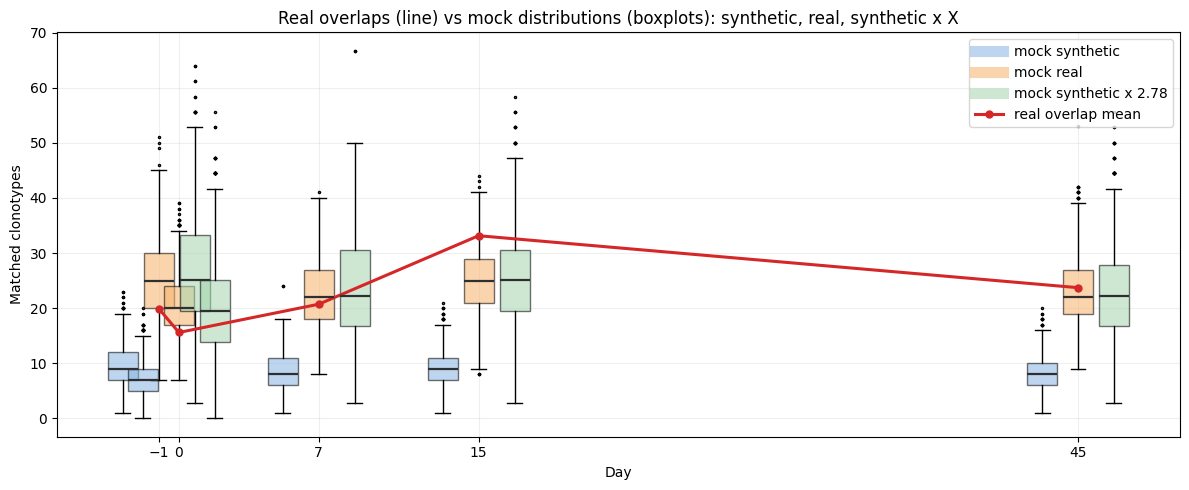

In [14]:
days_plot = sorted(df_res_synth["day"].unique().tolist())

def _collect_mock_by_day(df_in, value_col="mock_n"):
    out = {d: [] for d in days_plot}
    for _, row in df_in.iterrows():
        d = int(row["day"])
        out[d].extend([float(x) for x in row[value_col]])
    return out

syn_mock_by_day = _collect_mock_by_day(df_res_synth, "mock_n")
real_mock_by_day = _collect_mock_by_day(df_res_real, "mock_n")
syn_scaled_mock_by_day = _collect_mock_by_day(df_res_synth_scaled, "mock_n")

real_mean_by_day = df_res_real.groupby("day", as_index=False)["matched_n_real"].mean().sort_values("day")

fig, ax = plt.subplots(figsize=(12, 5))
width = 1.5
offsets = [-1.8, 0.0, 1.8]

for label, by_day, color, off in [
    ("mock synthetic", syn_mock_by_day, "#87b4e3", offsets[0]),
    ("mock real", real_mock_by_day, "#f6b26b", offsets[1]),
    (f"mock synthetic x {X_scale:.2f}", syn_scaled_mock_by_day, "#a4d4ae", offsets[2]),
]:
    data = [by_day[d] if len(by_day[d]) else [np.nan] for d in days_plot]
    pos = [d + off for d in days_plot]
    bp = ax.boxplot(
        data,
        positions=pos,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        boxprops=dict(facecolor=color, alpha=0.55),
        medianprops=dict(color="#2f2f2f", linewidth=1.6),
        flierprops=dict(markersize=1.5),
    )
    ax.plot([], [], color=color, linewidth=8, alpha=0.55, label=label)

ax.plot(real_mean_by_day["day"], real_mean_by_day["matched_n_real"], "-o", color="#d62728", linewidth=2.2, markersize=5, label="real overlap mean")
ax.set_xticks(days_plot)
ax.set_xlabel("Day")
ax.set_ylabel("Matched clonotypes")
ax.set_title("Real overlaps (line) vs mock distributions (boxplots): synthetic, real, synthetic x X")
ax.grid(alpha=0.2)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()